In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
print(df.info())
print('\n')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None




,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,23.799293,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,17.596074,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,6.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df_processed = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

df_processed['Sex'] = df_processed['Sex'].map({'male': 0, 'female': 1})

df_processed = pd.get_dummies(df_processed, columns=['Embarked'], drop_first=True)

display(df_processed.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 9)
X_test shape: (179, 9)
y_train shape: (712,)
y_test shape: (179,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc = DecisionTreeClassifier(random_state=42)

dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.77


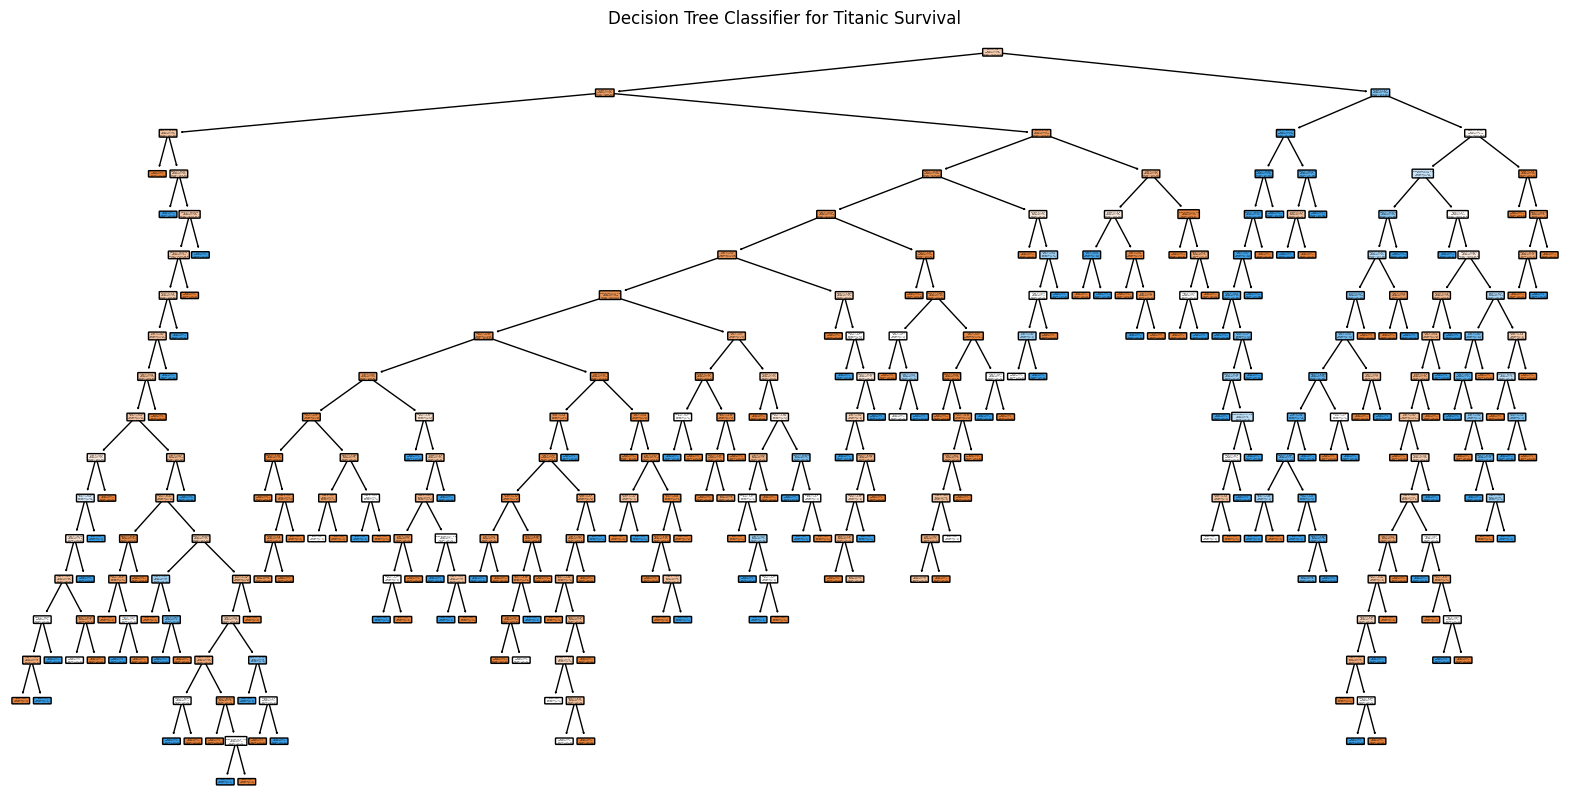

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("Decision Tree Classifier for Titanic Survival")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc_id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)

dtc_id3.fit(X_train, y_train)

y_pred_id3 = dtc_id3.predict(X_test)

accuracy_id3 = accuracy_score(y_test, y_pred_id3)

print(f"ID3-like Model Accuracy (Entropy): {accuracy_id3:.2f}")

ID3-like Model Accuracy (Entropy): 0.79


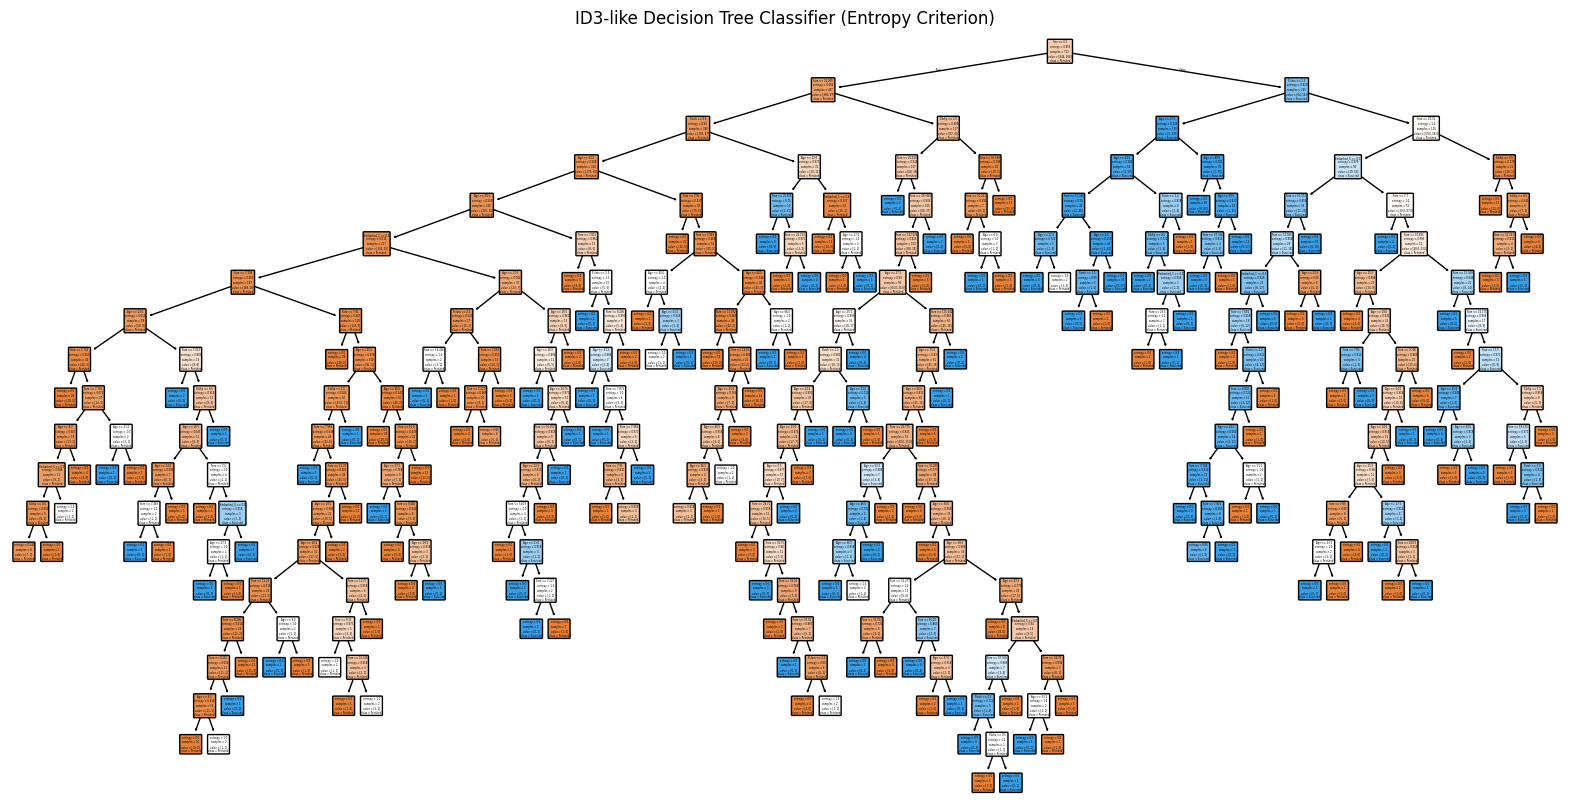

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_id3, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("ID3-like Decision Tree Classifier (Entropy Criterion)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dtc_c45_like = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

dtc_c45_like.fit(X_train, y_train)

y_pred_c45_like = dtc_c45_like.predict(X_test)

accuracy_c45_like = accuracy_score(y_test, y_pred_c45_like)

print(f"C4.5-like Model Accuracy (Entropy with max_depth=5): {accuracy_c45_like:.2f}")

C4.5-like Model Accuracy (Entropy with max_depth=5): 0.82


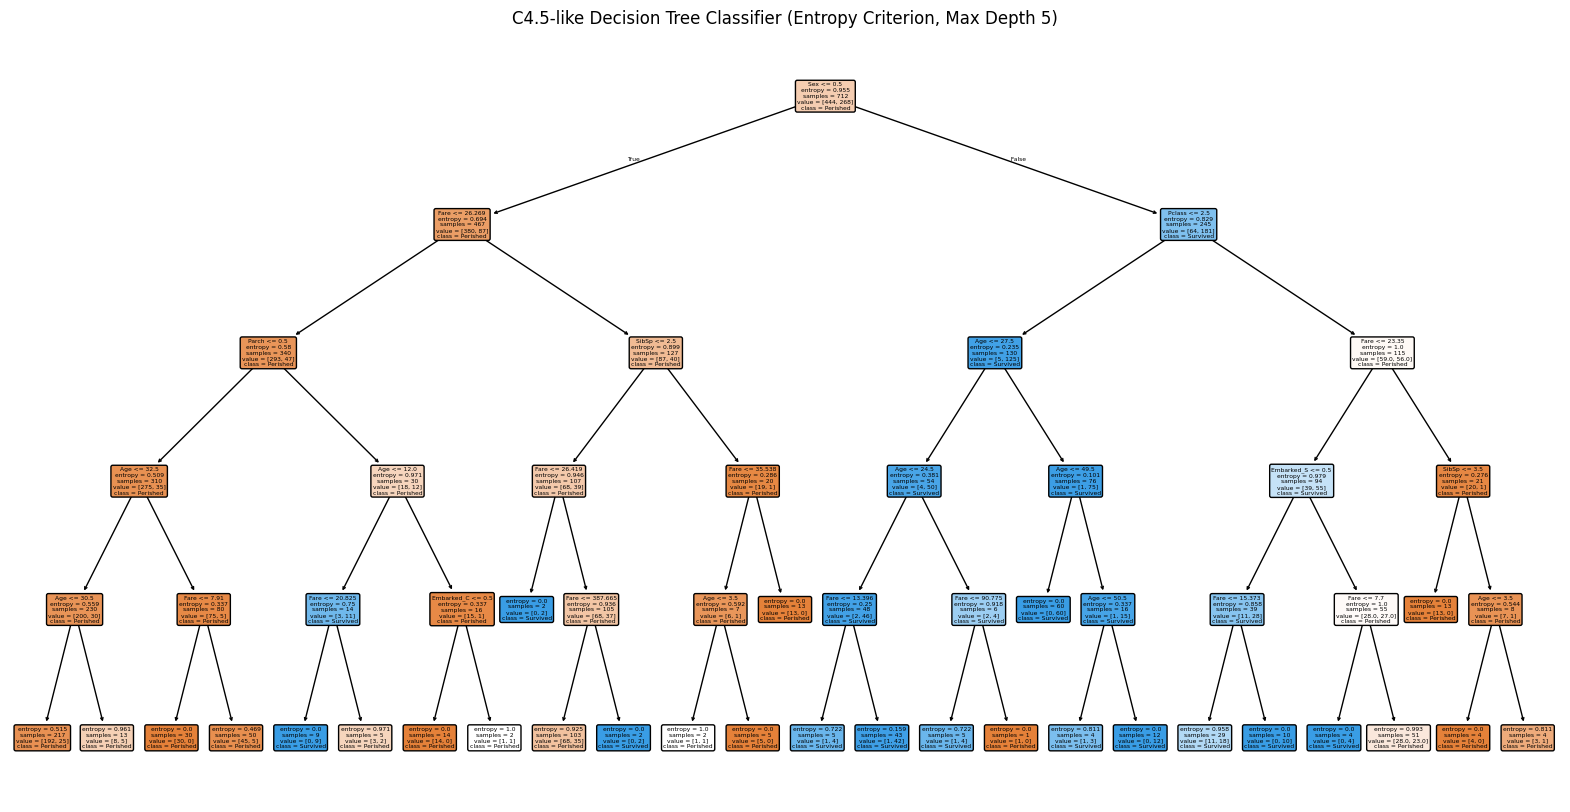

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtc_c45_like, feature_names=X.columns, class_names=['Perished', 'Survived'], filled=True, rounded=True)
plt.title("C4.5-like Decision Tree Classifier (Entropy Criterion, Max Depth 5)")
plt.show()